**Section 1: Import Libraries**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

**Section 2: Load Dataset**

In [ ]:
df = pd.read_csv("smart_accessibility_analytics_dataset.csv")

df.head()

,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority
0,LOC0001,Kolkata Botanical Garden,Tourist Attraction,Kolkata,West Bengal,22.691764,88.446606,Public,168,32.0,...,13.0,3,1.8,1.8,12.0,NaN,Partial,47.2,Poor,Medium
1,LOC0002,Hyderabad Municipal Office,Government Office,Hyderabad,Telangana,17.236120,78.585714,Public,57,12.0,...,12.0,3,1.9,1.8,15.0,NaN,No,36.1,Poor,High
2,LOC0003,Thane Government College,College,Thane,Maharashtra,19.107785,73.081622,Public,48,20.0,...,17.0,6,1.6,1.5,12.0,Poor,Yes,50.3,Poor,High
3,LOC0004,Nashik Green Park,Park,Nashik,Maharashtra,19.849054,73.865693,Public,38,22.0,...,21.0,5,3.2,3.1,12.0,NaN,Partial,38.2,Poor,High
4,LOC0005,Patna Domestic Airport,Airport,Patna,Bihar,25.647041,85.202726,Public,5,5.0,...,10.0,4,4.4,4.3,18.0,Good,Yes,100.0,Excellent,Low


**Section 3: Basic Information**

In [ ]:
print("Shape :", df.shape)

df.info()

Shape : (1000, 43)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 43 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Location_ID                   1000 non-null   object 
 1   Location_Name                 1000 non-null   object 
 2   Location_Type                 1000 non-null   object 
 3   City                          1000 non-null   object 
 4   State                         1000 non-null   object 
 5   Latitude                      999 non-null    float64
 6   Longitude                     999 non-null    float64
 7   Ownership_Type                1000 non-null   object 
 8   Building_Age_Years            1000 non-null   int64  
 9   Last_Renovation_Years_Ago     999 non-null    float64
 10  Number_of_Floors              1000 non-null   int64  
 11  Ramp_Available                1000 non-null   object 
 12  Elevator_Available            1000 non-null 

**Section 4: Statistical Summary**

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Location_ID,1000,1000,LOC1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Name,1000,594,Guwahati Collectorate Office,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_Type,1000,9,Government Office,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,26,Nashik,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,1000,15,Maharashtra,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,999.0,NaN,NaN,NaN,20.086236,6.011309,8.37782,17.287175,21.053347,25.446492,30.871147
Longitude,999.0,NaN,NaN,NaN,77.877617,4.663843,72.421459,73.853333,76.912553,80.153278,91.873532
Ownership_Type,1000,2,Public,701,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Building_Age_Years,1000.0,NaN,NaN,NaN,37.588,34.965939,1.0,15.0,28.0,49.0,200.0
Last_Renovation_Years_Ago,999.0,NaN,NaN,NaN,14.363363,8.713377,0.0,8.0,13.0,19.0,50.0


**Section 5: Missing Values**

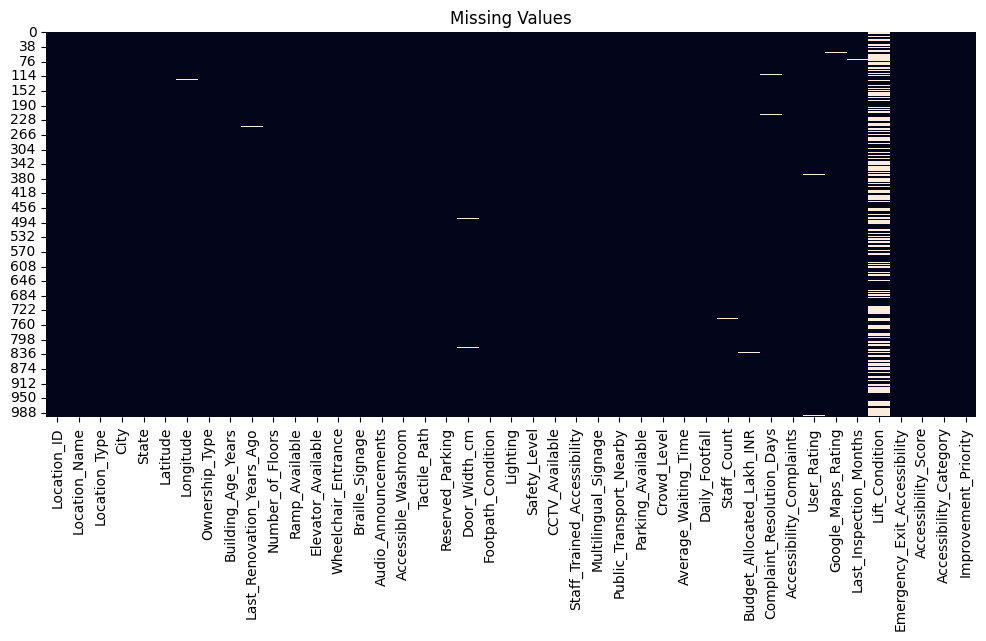

In [ ]:
#
missing = df.isnull().sum()
missing = missing[missing > 0]
missing

# Percentage
missing_percentage = (df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

# Visualization
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

**Section 6: Duplicate Records**

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


**Data Type Validation**

In [ ]:
df.dtypes

,0
Location_ID,object
Location_Name,object
Location_Type,object
City,object
State,object
Latitude,float64
Longitude,float64
Ownership_Type,object
Building_Age_Years,int64
Last_Renovation_Years_Ago,float64


**Unique Values**

In [ ]:
for column in df.columns:
    print(column)
    print(df[column].unique())
    print("----------------")

Location_ID
['LOC0001' 'LOC0002' 'LOC0003' 'LOC0004' 'LOC0005' 'LOC0006' 'LOC0007'
 'LOC0008' 'LOC0009' 'LOC0010' 'LOC0011' 'LOC0012' 'LOC0013' 'LOC0014'
 'LOC0015' 'LOC0016' 'LOC0017' 'LOC0018' 'LOC0019' 'LOC0020' 'LOC0021'
 'LOC0022' 'LOC0023' 'LOC0024' 'LOC0025' 'LOC0026' 'LOC0027' 'LOC0028'
 'LOC0029' 'LOC0030' 'LOC0031' 'LOC0032' 'LOC0033' 'LOC0034' 'LOC0035'
 'LOC0036' 'LOC0037' 'LOC0038' 'LOC0039' 'LOC0040' 'LOC0041' 'LOC0042'
 'LOC0043' 'LOC0044' 'LOC0045' 'LOC0046' 'LOC0047' 'LOC0048' 'LOC0049'
 'LOC0050' 'LOC0051' 'LOC0052' 'LOC0053' 'LOC0054' 'LOC0055' 'LOC0056'
 'LOC0057' 'LOC0058' 'LOC0059' 'LOC0060' 'LOC0061' 'LOC0062' 'LOC0063'
 'LOC0064' 'LOC0065' 'LOC0066' 'LOC0067' 'LOC0068' 'LOC0069' 'LOC0070'
 'LOC0071' 'LOC0072' 'LOC0073' 'LOC0074' 'LOC0075' 'LOC0076' 'LOC0077'
 'LOC0078' 'LOC0079' 'LOC0080' 'LOC0081' 'LOC0082' 'LOC0083' 'LOC0084'
 'LOC0085' 'LOC0086' 'LOC0087' 'LOC0088' 'LOC0089' 'LOC0090' 'LOC0091'
 'LOC0092' 'LOC0093' 'LOC0094' 'LOC0095' 'LOC0096' 'LOC0097' 'LOC

**Data Consistency Checks**

In [ ]:
df[df["Accessibility_Score"]>100]

,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority


**Outlier Detection**

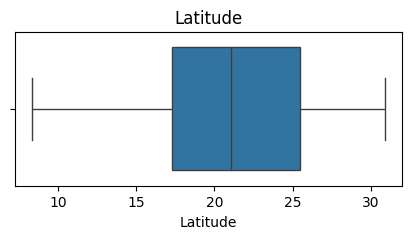

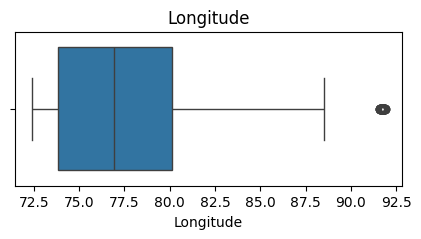

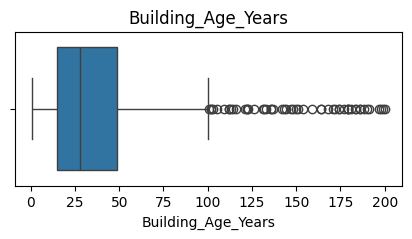

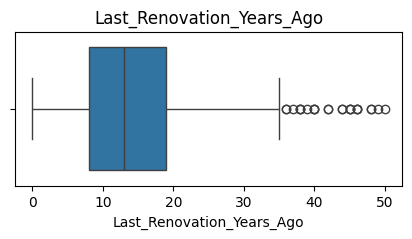

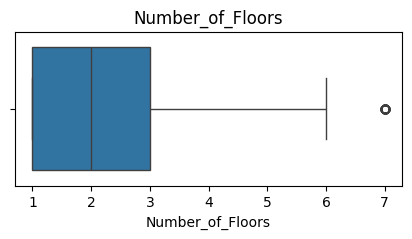

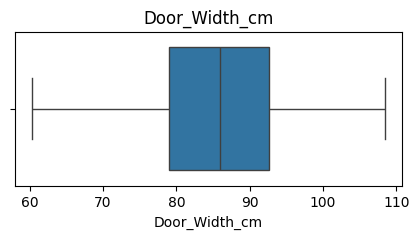

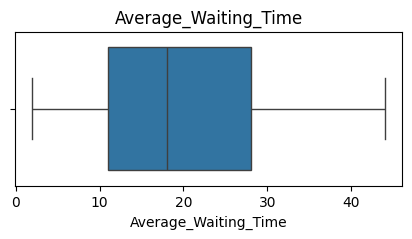

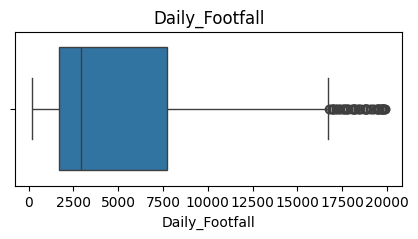

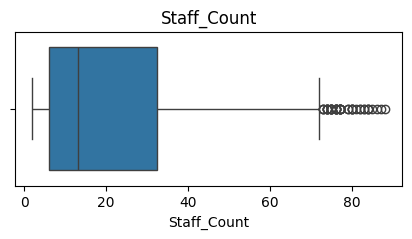

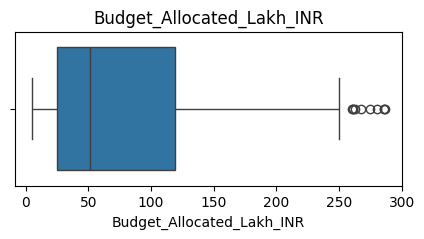

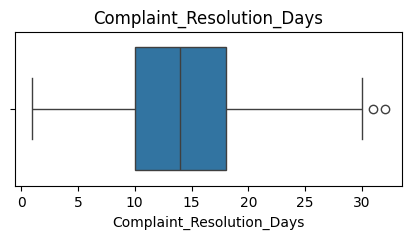

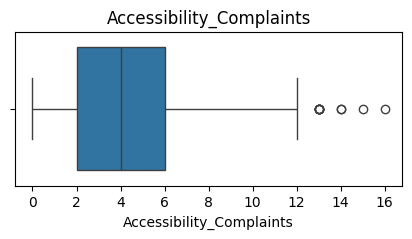

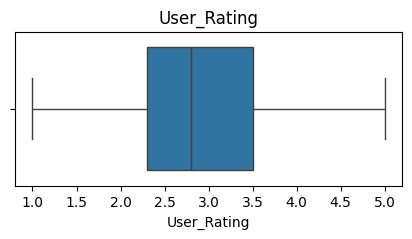

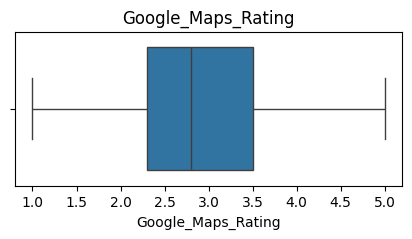

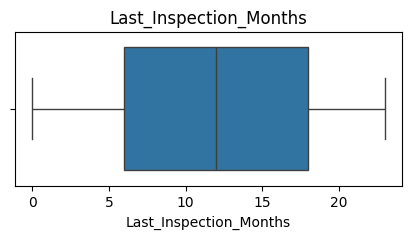

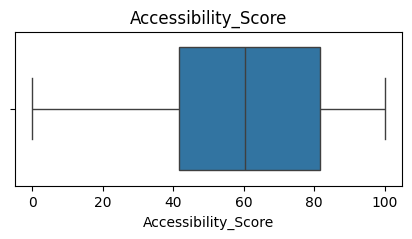

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

**Handle Missing Values**

In [ ]:
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:

    df[col] = df[col].fillna(df[col].mode()[0])

**Encode Categorical Variables**

In [ ]:
label_encoder = LabelEncoder()

for col in categorical_columns:
    if col not in ["Location_ID", "Location_Name", "Accessibility_Category", "Improvement_Priority"]:
        df[col] = label_encoder.fit_transform(df[col])

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(df[numerical_columns])

scaled_df = pd.DataFrame(
    scaled_features,
    columns=numerical_columns
)

**Final Dataset**

In [ ]:
print(df.shape)
df.head()

(1000, 43)


,Location_ID,Location_Name,Location_Type,City,State,Latitude,Longitude,Ownership_Type,Building_Age_Years,Last_Renovation_Years_Ago,...,Complaint_Resolution_Days,Accessibility_Complaints,User_Rating,Google_Maps_Rating,Last_Inspection_Months,Lift_Condition,Emergency_Exit_Accessibility,Accessibility_Score,Accessibility_Category,Improvement_Priority
0,LOC0001,Kolkata Botanical Garden,8,13,14,22.691764,88.446606,1,168,32.0,...,13.0,3,1.8,1.8,12.0,1,1,47.2,Poor,Medium
1,LOC0002,Hyderabad Municipal Office,3,8,12,17.236120,78.585714,1,57,12.0,...,12.0,3,1.9,1.8,15.0,1,0,36.1,Poor,High
2,LOC0003,Thane Government College,2,22,9,19.107785,73.081622,1,48,20.0,...,17.0,6,1.6,1.5,12.0,2,2,50.3,Poor,High
3,LOC0004,Nashik Green Park,6,18,9,19.849054,73.865693,1,38,22.0,...,21.0,5,3.2,3.1,12.0,1,1,38.2,Poor,High
4,LOC0005,Patna Domestic Airport,0,19,2,25.647041,85.202726,1,5,5.0,...,10.0,4,4.4,4.3,18.0,1,2,100.0,Excellent,Low


**Save Clean Dataset**

In [ ]:
df.to_csv(
    "cleaned_accessibility_dataset.csv",
    index=False
)